# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *

# DGP

In [6]:
# bernoulli specification
dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(0.1, 0.01), UnivariateGaussian(0.2, std=0.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# continuous specification
# dgp_params = {
#     'n_experiments': 100, 
#     'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

dgp = RCTs(**dgp_params)

In [7]:
samples = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [8]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples)

# Selection

In [9]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [10]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,0.202174
True Policy Value,0.200820
Winner's Curse,0.001354


In [11]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.2s finished


In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.1104 (0.0004)
  - Average Estimated Value: 1.1459 (0.0009)
  - Average Winner's Curse (%): 35.52% (0.90%)


# Estimating Winner's Curse

In [22]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [15]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


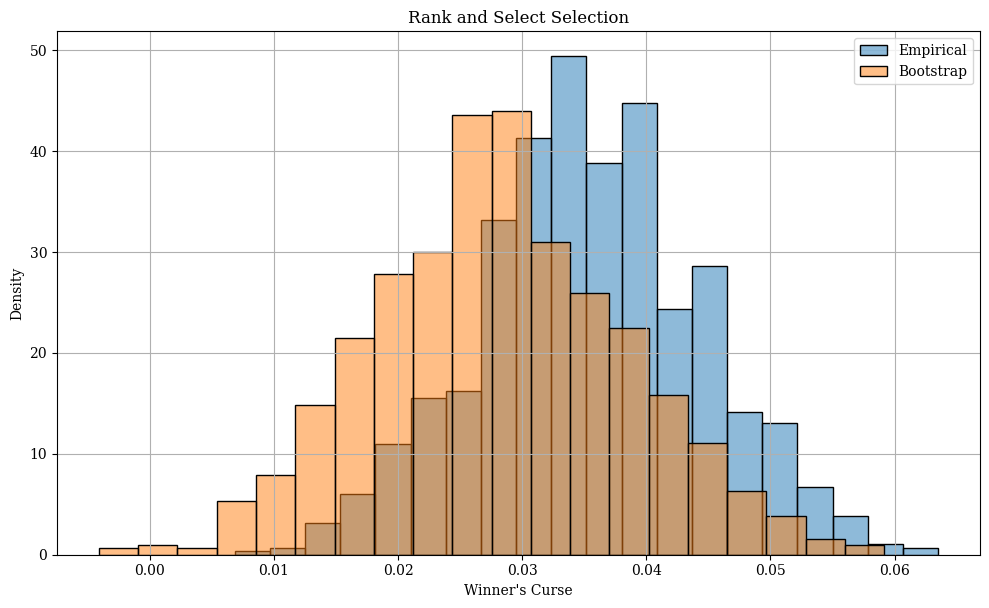

In [16]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [17]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


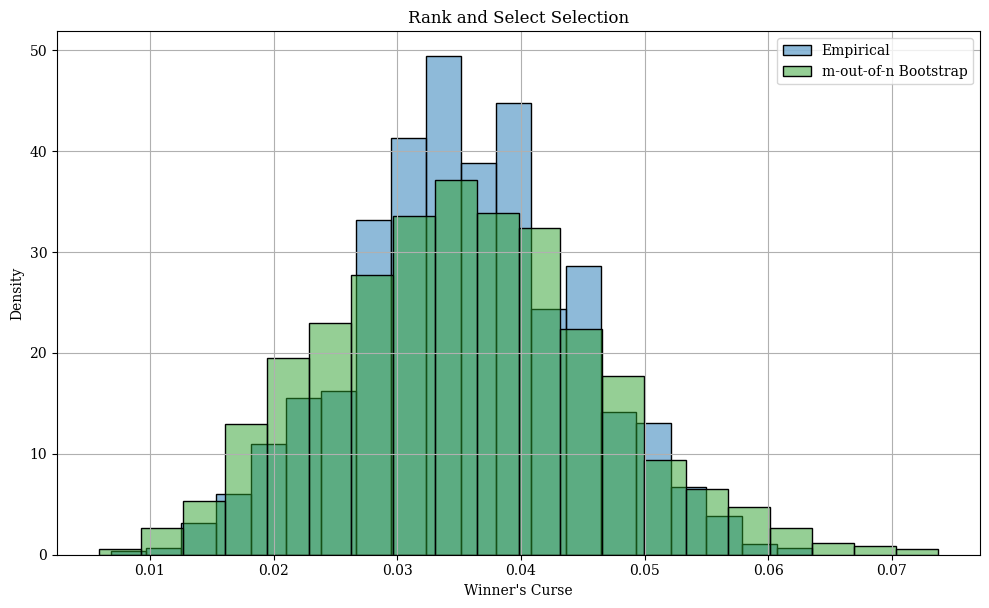

In [18]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [19]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


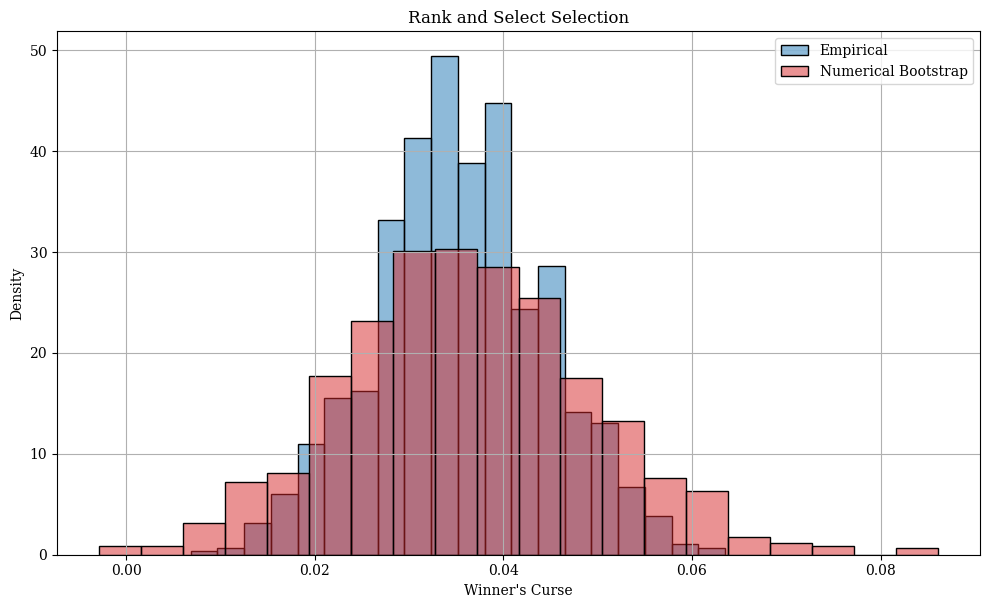

In [20]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [21]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [11]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Shrinkage with Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Selective Inference\n(Andrews et al. 2024)'
    }
}

In [12]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.2s finished



Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0764 (0.0042)
  - No Correction: 1.1196 (0.0088)
  - Standard Bootstrap: 1.0848 (0.0099)
  - m-out-of-n Bootstrap: 1.0775 (0.0100)
  - Numerical Bootstrap: 1.0758 (0.0102)
  - Shrinkage with Bayes: 1.1086 (0.0087)
  - Selective Inference
(Andrews et al. 2024): 1.0038 (0.0411)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 43.15% (9.10%)
  - Standard Bootstrap: 8.42% (9.99%)
  - m-out-of-n Bootstrap: 1.13% (10.03%)
  - Numerical Bootstrap: -0.59% (10.24%)
  - Shrinkage with Bayes: 32.22% (9.02%)
  - Selective Inference
(Andrews et al. 2024): -72.66% (40.48%)
Median Winner's Curse: 
  - No Correction: 44.99% (9.10%)
  - Standard Bootstrap: 9.37% (9.99%)
  - m-out-of-n Bootstrap: 1.23% (10.03%)
  - Numerical Bootstrap: -0.15% (10.24%)
  - Shrinkage with Bayes: 35.28% (9.02%)
  - Selective Inference
(Andrews et al. 2024): 1.10% (40.48%)

Sample Splitting: 
  - True Value: 1.0684 (0.0046)
  - Estimated Value: 1

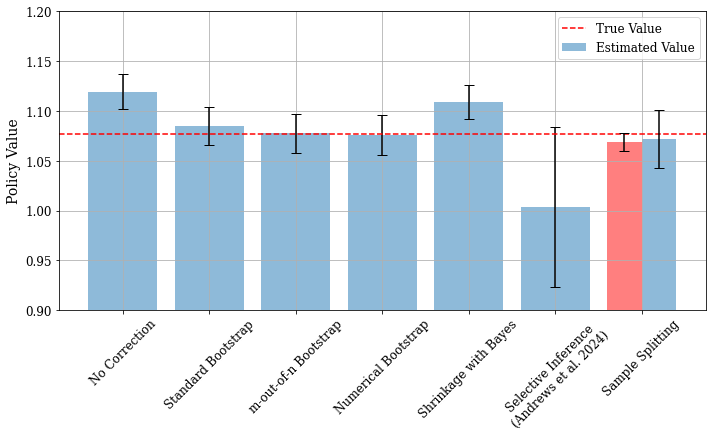

In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [14]:
np.median(wc_measures_dict['rank_and_select_cond_selective_inference_val_est_arr'])

1.0720160627749808

# Comparative Statics

## Delta Tau

In [81]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

### $\tau_1 = 1.0$

In [82]:
base_tau = 1.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.7s finished


In [83]:
with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
    pickle.dump(delta_tau1_result_dict, f)

with open('results/ab_test_delta_tau1.pkl', 'rb') as f:
    delta_tau1_result_dict = pickle.load(f)

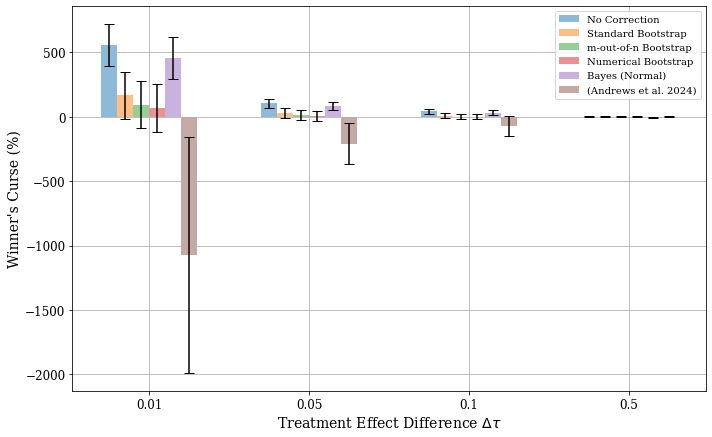

$\Delta\tau=0.01$  $\Delta\tau=0.05$  \
No Correction         Mean               557.93             104.41   
                      Median             581.37             111.14   
                      S.E.                83.15              16.99   
Standard Bootstrap    Mean               166.07              28.27   
                      Median             149.28              25.23   
                      S.E.                92.93              18.92   
m-out-of-n Bootstrap  Mean                92.06              13.49   
                      Median              59.35               9.82   
                      S.E.                92.85              18.91   
Numerical Bootstrap   Mean                66.38               8.69   
                      Median              62.25               4.59   
                      S.E.                95.59              19.44   
Bayes (Normal)        Mean               454.27              83.21   
                      Median             474.08              88.12   
                      S.E.                82.37              16.84   
(Andrews et al. 2024) Mean             -1074.33            -207.95   
                      Median              73.82               5.99   
                      S.E.               468.06              81.55   

                              $\Delta\tau=0.1$  $\Delta\tau=0.5$  
No Correction         Mean               43.15             -0.02  
                      Median             44.99             -0.12  
                      S.E.                9.10              2.02  
Standard Bootstrap    Mean                8.42             -0.34  
                      Median              9.37              0.04  
                      S.E.                9.99              2.07  
m-out-of-n Bootstrap  Mean                1.13             -0.61  
                      Median              1.23             -0.78  
                      S.E.               10.03              2.08  
Numerical Bootstrap   Mean               -0.59             -0.47  
                      Median             -0.15             -0.64  
                      S.E.               10.24              2.08  
Bayes (Normal)        Mean               32.22             -2.94  
                      Median             35.28             -2.99  
                      S.E.                9.02              2.00  
(Andrews et al. 2024) Mean              -72.66             -0.06  
                      Median              1.10             -0.12  
                      S.E.               40.48              2.02

In [84]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

### $\tau_1 = 2.0$

In [85]:
base_tau = 2.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau2_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau2_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.7s finished


In [86]:
with open('results/ab_test_delta_tau2.pkl', 'wb') as f:
    pickle.dump(delta_tau2_result_dict, f)

with open('results/ab_test_delta_tau2.pkl', 'rb') as f:
    delta_tau2_result_dict = pickle.load(f)

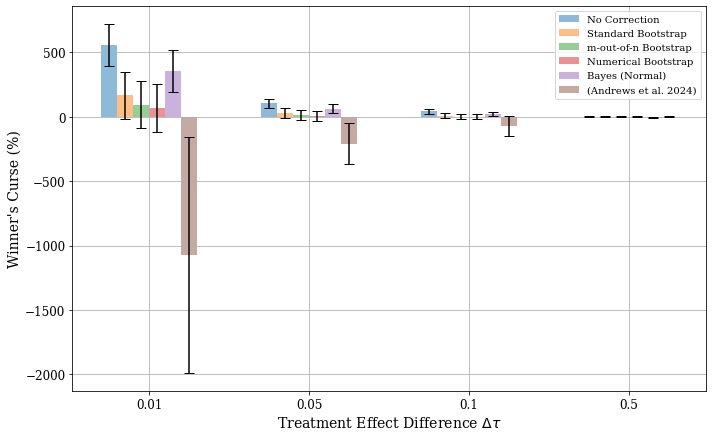

$\Delta\tau=0.01$  $\Delta\tau=0.05$  \
No Correction         Mean               557.93             104.41   
                      Median             581.37             111.14   
                      S.E.                83.15              16.99   
Standard Bootstrap    Mean               166.07              28.27   
                      Median             149.28              25.23   
                      S.E.                92.93              18.92   
m-out-of-n Bootstrap  Mean                92.06              13.49   
                      Median              59.35               9.82   
                      S.E.                92.85              18.91   
Numerical Bootstrap   Mean                66.38               8.69   
                      Median              62.25               4.59   
                      S.E.                95.59              19.44   
Bayes (Normal)        Mean               356.55              63.64   
                      Median             366.95              68.36   
                      S.E.                82.42              16.85   
(Andrews et al. 2024) Mean             -1074.33            -207.95   
                      Median              73.82               5.99   
                      S.E.               468.06              81.55   

                              $\Delta\tau=0.1$  $\Delta\tau=0.5$  
No Correction         Mean               43.15             -0.02  
                      Median             44.99             -0.12  
                      S.E.                9.10              2.02  
Standard Bootstrap    Mean                8.42             -0.34  
                      Median              9.37              0.04  
                      S.E.                9.99              2.07  
m-out-of-n Bootstrap  Mean                1.13             -0.61  
                      Median              1.23             -0.78  
                      S.E.               10.03              2.08  
Numerical Bootstrap   Mean               -0.59             -0.47  
                      Median             -0.15             -0.64  
                      S.E.               10.24              2.08  
Bayes (Normal)        Mean               22.45             -4.88  
                      Median             26.37             -5.16  
                      S.E.                9.03              2.00  
(Andrews et al. 2024) Mean              -72.66             -0.06  
                      Median              1.10             -0.12  
                      S.E.               40.48              2.02

In [87]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Sample Size

In [73]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [74]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 500
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   13.7s finished


In [101]:
# with open('results/ab_test_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

with open('results/ab_test_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

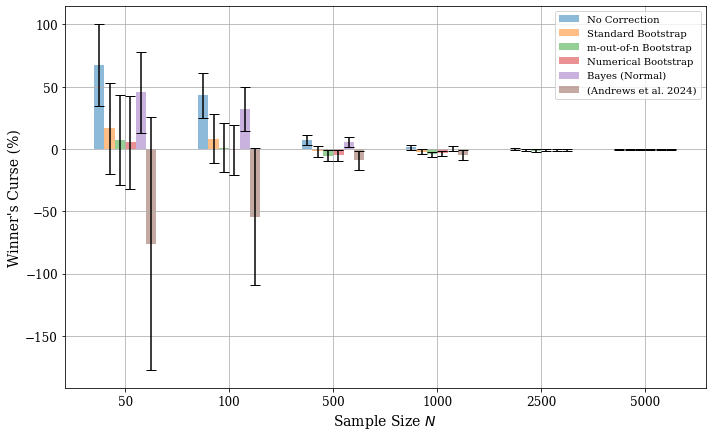

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction         Mean     67.62    43.15     7.60      1.50     -0.22   
                      Median   71.96    44.99     7.73      3.15     -0.17   
                      S.E.     16.81     9.10     2.01      0.96      0.41   
Standard Bootstrap    Mean     16.62     8.42    -1.65     -1.96     -0.61   
                      Median   20.49     9.37     1.75     -0.50     -0.39   
                      S.E.     18.56     9.99     2.20      1.04      0.43   
m-out-of-n Bootstrap  Mean      7.21     1.13    -5.31     -4.18     -1.11   
                      Median   10.34     1.23    -2.90     -2.67     -0.71   
                      S.E.     18.55    10.03     2.24      1.07      0.44   
Numerical Bootstrap   Mean      5.46    -0.59    -5.09     -3.26     -0.87   
                      Median    6.64    -0.15    -1.69     -1.60     -0.16   
                      S.E.     19.00    10.24     2.29      1.09      0.43   
Bayes (Normal)        Mean     45.45    32.22     5.41      0.40     -0.66   
                      Median   48.34    35.28     5.55      2.01     -0.60   
                      S.E.     16.53     9.02     2.01      0.95      0.41   
(Andrews et al. 2024) Mean    -76.10   -54.16    -9.09     -4.50     -0.37   
                      Median    9.31     1.99     1.49      1.79     -0.17   
                      S.E.     51.80    28.16     3.73      2.08      0.42   

                              $N=5000$  
No Correction         Mean       -0.27  
                      Median     -1.03  
                      S.E.        0.19  
Standard Bootstrap    Mean       -0.29  
                      Median     -1.18  
                      S.E.        0.19  
m-out-of-n Bootstrap  Mean       -0.30  
                      Median     -1.07  
                      S.E.        0.20  
Numerical Bootstrap   Mean       -0.39  
                      Median     -1.05  
                      S.E.        0.19  
Bayes (Normal)        Mean       -0.49  
                      Median     -1.25  
                      S.E.        0.19  
(Andrews et al. 2024) Mean       -0.27  
                      Median     -1.03  
                      S.E.        0.19

In [102]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [105]:
print(wc_stats_df.map('{:.2f}\%'.format).style.to_latex())

\begin{tabular}{llllllll}
 &  & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 67.62\% & 43.15\% & 7.60\% & 1.50\% & -0.22\% & -0.27\% \\
 & Median & 71.96\% & 44.99\% & 7.73\% & 3.15\% & -0.17\% & -1.03\% \\
 & S.E. & 16.81\% & 9.10\% & 2.01\% & 0.96\% & 0.41\% & 0.19\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 16.62\% & 8.42\% & -1.65\% & -1.96\% & -0.61\% & -0.29\% \\
 & Median & 20.49\% & 9.37\% & 1.75\% & -0.50\% & -0.39\% & -1.18\% \\
 & S.E. & 18.56\% & 9.99\% & 2.20\% & 1.04\% & 0.43\% & 0.19\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 7.21\% & 1.13\% & -5.31\% & -4.18\% & -1.11\% & -0.30\% \\
 & Median & 10.34\% & 1.23\% & -2.90\% & -2.67\% & -0.71\% & -1.07\% \\
 & S.E. & 18.55\% & 10.03\% & 2.24\% & 1.07\% & 0.44\% & 0.20\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & 5.46\% & -0.59\% & -5.09\% & -3.26\% & -0.87\% & -0.39\% \\
 & Median & 6.64\% & -0.15\% & -1.69\% & -1.60\% & -0.16\% & -1.

## Response STD

In [93]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [94]:
response_std_list = [0.5, 1, 2, 3, 4, 5]

response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Response Standard Deviation = 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished


In [98]:
# with open('results/ab_test_response_std.pkl', 'wb') as f:
#     pickle.dump(response_std_result_dict, f)

with open('results/ab_test_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

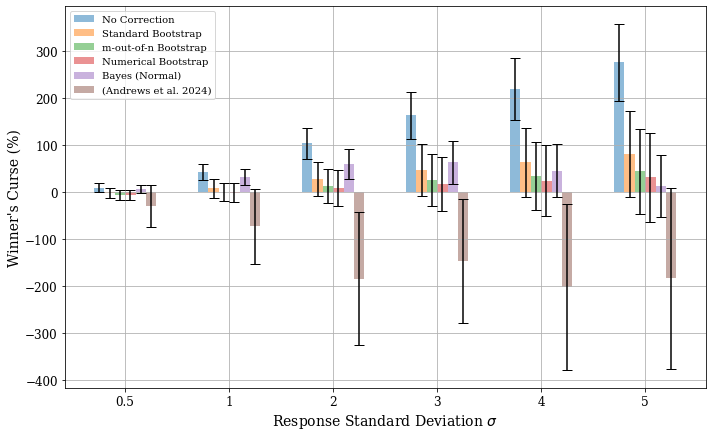

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  \
No Correction         Mean            9.72       43.15      104.41   
                      Median          8.71       44.99      111.14   
                      S.E.            4.83        9.10       16.99   
Standard Bootstrap    Mean           -2.25        8.42       28.27   
                      Median         -2.79        9.37       25.23   
                      S.E.            5.29        9.99       18.92   
m-out-of-n Bootstrap  Mean           -5.39        1.13       13.49   
                      Median         -7.35        1.23        9.82   
                      S.E.            5.35       10.03       18.91   
Numerical Bootstrap   Mean           -5.42       -0.59        8.69   
                      Median         -6.46       -0.15        4.59   
                      S.E.            5.42       10.24       19.44   
Bayes (Normal)        Mean            7.02       32.22       60.05   
                      Median          5.97       35.28       63.63   
                      S.E.            4.82        9.02       16.39   
(Andrews et al. 2024) Mean          -29.00      -72.66     -183.80   
                      Median         -3.18        1.10        6.27   
                      S.E.           23.00       40.48       72.34   

                              $\sigma=3$  $\sigma=4$  $\sigma=5$  
No Correction         Mean        163.63      219.91      276.59  
                      Median      173.55      232.55      290.69  
                      S.E.         25.20       33.47       41.72  
Standard Bootstrap    Mean         47.59       64.15       81.42  
                      Median       42.55       56.20       71.37  
                      S.E.         28.11       37.38       46.62  
m-out-of-n Bootstrap  Mean         25.35       34.52       44.26  
                      Median       15.17       21.54       27.28  
                      S.E.         28.09       37.34       46.56  
Numerical Bootstrap   Mean         17.91       24.48       31.58  
                      Median        9.30       21.03       30.03  
                      S.E.         28.89       38.43       47.93  
Bayes (Normal)        Mean         64.12       46.20       14.21  
                      Median       75.02       56.42       19.51  
                      S.E.         23.26       29.10       33.75  
(Andrews et al. 2024) Mean       -146.01     -201.95     -183.15  
                      Median       22.27        9.93       35.23  
                      S.E.         66.86       90.24       98.28

In [99]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [100]:
# add percentage sign to all entries
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{llllllll}
 &  & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 9.72\% & 43.15\% & 104.41\% & 163.63\% & 219.91\% & 276.59\% \\
 & Median & 8.71\% & 44.99\% & 111.14\% & 173.55\% & 232.55\% & 290.69\% \\
 & S.E. & 4.83\% & 9.10\% & 16.99\% & 25.20\% & 33.47\% & 41.72\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & -2.25\% & 8.42\% & 28.27\% & 47.59\% & 64.15\% & 81.42\% \\
 & Median & -2.79\% & 9.37\% & 25.23\% & 42.55\% & 56.20\% & 71.37\% \\
 & S.E. & 5.29\% & 9.99\% & 18.92\% & 28.11\% & 37.38\% & 46.62\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & -5.39\% & 1.13\% & 13.49\% & 25.35\% & 34.52\% & 44.26\% \\
 & Median & -7.35\% & 1.23\% & 9.82\% & 15.17\% & 21.54\% & 27.28\% \\
 & S.E. & 5.35\% & 10.03\% & 18.91\% & 28.09\% & 37.34\% & 46.56\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -5.42\% & -0.59\% & 8.69\% & 17.91\% & 24.48\% & 31.58\% \\
 & Median & -6.46\% & -0.1

## $\Delta\tau / \sigma$

In [32]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

ratio_list = [0.01, 0.1, 0.5, 1, 2]

samp_vol_list = [1, 2, 3]


In [33]:
ratio_result_dict = {}

for ratio in ratio_list:
    for samp_vol in samp_vol_list:
        delta_tau = samp_vol * ratio
        print(f'\nRatio = {ratio}; Sampling Volatility = {samp_vol}; Delta tau= {delta_tau}')

        response_vol = np.sqrt(data_params['sample_size'] / 2) * samp_vol

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_vol), UnivariateGaussian(0, std=response_vol)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, samp_vol, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Ratio = 0.01; Sampling Volatility = 1; Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 0.01; Sampling Volatility = 2; Delta tau= 0.02
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 0.01; Sampling Volatility = 3; Delta tau= 0.03
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 2; Sampling Volatility = 2; Delta tau= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 2; Sampling Volatility = 3; Delta tau= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.5s finished


In [34]:
with open('results/ab_test_ratio.pkl', 'wb') as f:
    pickle.dump(ratio_result_dict, f)

with open('results/ab_test_ratio.pkl', 'rb') as f:
    ratio_result_dict = pickle.load(f)

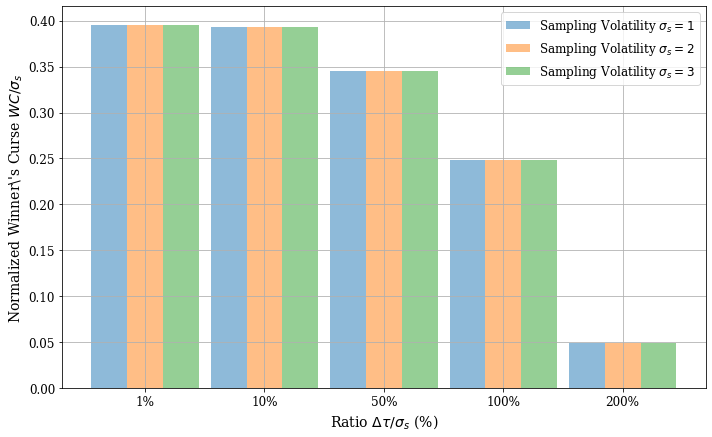

0.01  \
                             $(\Delta\tau, \sigma_s) = (0.01, 1)$   
No Correction         Mean                                 0.3957   
                      Median                               0.4111   
                      S.E.                                 0.0587   
Standard Bootstrap    Mean                                 0.1186   
                      Median                               0.1171   
                      S.E.                                 0.0656   
m-out-of-n Bootstrap  Mean                                 0.0662   
                      Median                               0.0525   
                      S.E.                                 0.0655   
Numerical Bootstrap   Mean                                 0.0480   
                      Median                               0.0523   
                      S.E.                                 0.0675   
Bayes (Normal)        Mean                                -0.0656   
                      Median                              -0.0563   
                      S.E.                                 0.0397   
(Andrews et al. 2024) Mean                                -0.1502   
                      Median                               0.1198   
                      S.E.                                 0.1215   

                                                                   \
                             $(\Delta\tau, \sigma_s) = (0.02, 2)$   
No Correction         Mean                                 0.3957   
                      Median                               0.4111   
                      S.E.                                 0.1174   
Standard Bootstrap    Mean                                 0.1186   
                      Median                               0.1171   
                      S.E.                                 0.1312   
m-out-of-n Bootstrap  Mean                                 0.0662   
                      Median                               0.0525   
                      S.E.                                 0.1311   
Numerical Bootstrap   Mean                                 0.0480   
                      Median                               0.0523   
                      S.E.                                 0.1351   
Bayes (Normal)        Mean                                -0.1998   
                      Median                              -0.1955   
                      S.E.                                 0.0406   
(Andrews et al. 2024) Mean                                 0.0464   
                      Median                               0.1981   
                      S.E.                                 0.1825   

                                                                   \
                             $(\Delta\tau, \sigma_s) = (0.03, 3)$   
No Correction         Mean                                 0.3957   
                      Median                               0.4111   
                      S.E.                                 0.1761   
Standard Bootstrap    Mean                                 0.1119   
                      Median                               0.1136   
                      S.E.                                 0.1882   
m-out-of-n Bootstrap  Mean                                 0.0595   
                      Median                               0.0503   
                      S.E.                                 0.1880   
Numerical Bootstrap   Mean                                 0.0478   
                      Median                               0.0523   
                      S.E.                                 0.1938   
Bayes (Normal)        Mean                                -0.2018   
                      Median                              -0.1992   
                      S.E.                                 0.0336   
(Andrews et al. 2024) Mean                                 0.1565   
                      Median                             

In [35]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    data[(delta_tau, samp_vol)]['No Correction'] = {
        'Mean': result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol, 
        'Median': np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']) / samp_vol, 
        'S.E.': result_dict[key][f'{optimizer_key}_nc_wc_se'], 
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        median_wc = np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr']) / samp_vol
        se_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, samp_vol)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma_s) = ({}, {})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, samp_vol)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(samp_vol_list)

for idx, samp_vol in enumerate(samp_vol_list):
    bar_values = [data[(dt, vol)]['No Correction']['Mean'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]
    bar_errors = [1.96 * data[(dt, vol)]['No Correction']['S.E.'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(samp_vol_list) + bar_width / 2 / len(samp_vol_list), 
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(samp_vol_list),
        label=r'Sampling Volatility $\sigma_s={}$'.format(samp_vol)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma_s$ (%)', fontsize=axis_label_size)
ax.set_ylabel(r'Normalized Winner\'s Curse $WC / \sigma_s$', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=[f'{item:.0%}' for item in ratio_list], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [39]:
print(wc_stats_df[[0.1, 1]].map(lambda x: f'{x:.4f}').style.to_latex())

\begin{tabular}{llllllll}
 &  & \multicolumn{3}{r}{0.100000} & \multicolumn{3}{r}{1.000000} \\
 &  & $(\Delta	au, \sigma_s) = (0.1, 1)$ & $(\Delta	au, \sigma_s) = (0.2, 2)$ & $(\Delta	au, \sigma_s) = (0.30000000000000004, 3)$ & $(\Delta	au, \sigma_s) = (1, 1)$ & $(\Delta	au, \sigma_s) = (2, 2)$ & $(\Delta	au, \sigma_s) = (3, 3)$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 0.3932 & 0.3932 & 0.3932 & 0.2480 & 0.2480 & 0.2480 \\
 & Median & 0.4111 & 0.4111 & 0.4111 & 0.2617 & 0.2617 & 0.2617 \\
 & S.E. & 0.0588 & 0.1177 & 0.1765 & 0.0665 & 0.1331 & 0.1996 \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 0.1164 & 0.1164 & 0.1099 & 0.0312 & 0.0312 & 0.0509 \\
 & Median & 0.1048 & 0.1048 & 0.1043 & 0.0241 & 0.0241 & 0.0510 \\
 & S.E. & 0.0658 & 0.1315 & 0.1886 & 0.0724 & 0.1449 & 0.2014 \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 0.0640 & 0.0640 & 0.0575 & -0.0186 & -0.0186 & 0.0081 \\
 & Median & 0.0403 & 0.0403 & 0.0399 & -0.0251 & -0.0251 & 0.0066 \\
 & S.E. & 0.0657 & 0.1314

## Noise distribution

In [38]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [39]:
noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    'Student T (Dof = 100)': StudentT(100), 
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Student T (Dof = 100)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished


In [61]:
# with open('results/ab_test_noise_dstn.pkl', 'wb') as f:
#     pickle.dump(noise_dstn_result_dict, f)

with open('results/ab_test_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

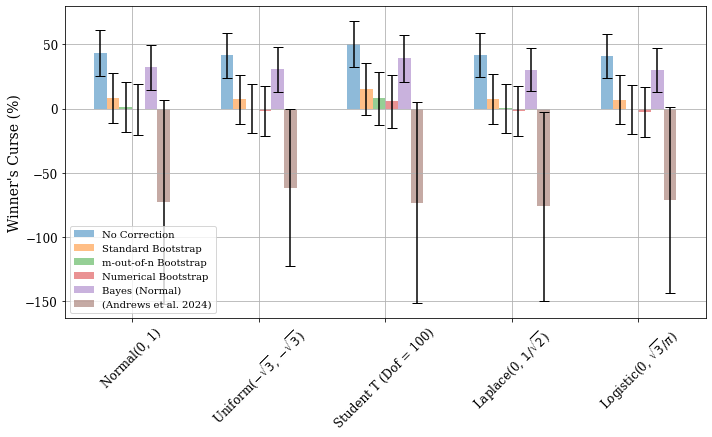

Normal(0, 1)  Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction         Mean           43.15                              41.52   
                      Median         44.99                              39.93   
                      S.E.            9.10                               8.83   
Standard Bootstrap    Mean            8.42                               7.23   
                      Median          9.37                               8.74   
                      S.E.            9.99                               9.71   
m-out-of-n Bootstrap  Mean            1.13                              -0.13   
                      Median          1.23                               1.53   
                      S.E.           10.03                               9.72   
Numerical Bootstrap   Mean           -0.59                              -1.97   
                      Median         -0.15                              -1.15   
                      S.E.           10.24                               9.94   
Bayes (Normal)        Mean           32.22                              30.51   
                      Median         35.28                              28.58   
                      S.E.            9.02                               8.77   
(Andrews et al. 2024) Mean          -72.66                             -61.35   
                      Median          1.10                              -3.90   
                      S.E.           40.48                              30.99   

                              Student T (Dof = 100)  Laplace(0, $1/\sqrt{2}$)  \
No Correction         Mean                    50.32                     41.66   
                      Median                  43.46                     37.57   
                      S.E.                     9.30                      8.77   
Standard Bootstrap    Mean                    15.05                      7.53   
                      Median                   8.53                      6.01   
                      S.E.                    10.28                      9.75   
m-out-of-n Bootstrap  Mean                     7.99                      0.23   
                      Median                   0.82                      1.53   
                      S.E.                    10.39                      9.76   
Numerical Bootstrap   Mean                     5.70                     -1.97   
                      Median                  -2.57                     -0.47   
                      S.E.                    10.57                     10.00   
Bayes (Normal)        Mean                    39.08                     30.47   
                      Median                  32.60                     26.50   
                      S.E.                     9.22                      8.69   
(Andrews et al. 2024) Mean                   -73.05                    -76.03   
                      Median                   2.55                      4.00   
                      S.E.                    39.98                     37.44   

                              Logistic(0, $\sqrt{3} / \pi$)  
No Correction         Mean                            41.09  
                      Median                          37.58  
                      S.E.                             8.72  
Standard Bootstrap    Mean                             6.86  
                      Median                           4.62  
                      S.E.                             9.69  
m-out-of-n Bootstrap  Mean                            -0.50  
                      Median                          -2.46  
                      S.E.                             9.70  
Numerical Bootstrap   Mean                            -2.49  
                      Median                          -4.10  
                      S.E.                             9.95  
Bayes (Normal)        Mean                            29.96  
                      Median                          26.93  
                    

In [62]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [63]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{lllllll}
 &  & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Student T (Dof = 100) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\multirow[c]{3}{*}{No Correction} & Mean & 43.15\% & 41.52\% & 50.32\% & 41.66\% & 41.09\% \\
 & Median & 44.99\% & 39.93\% & 43.46\% & 37.57\% & 37.58\% \\
 & S.E. & 9.10\% & 8.83\% & 9.30\% & 8.77\% & 8.72\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 8.42\% & 7.23\% & 15.05\% & 7.53\% & 6.86\% \\
 & Median & 9.37\% & 8.74\% & 8.53\% & 6.01\% & 4.62\% \\
 & S.E. & 9.99\% & 9.71\% & 10.28\% & 9.75\% & 9.69\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 1.13\% & -0.13\% & 7.99\% & 0.23\% & -0.50\% \\
 & Median & 1.23\% & 1.53\% & 0.82\% & 1.53\% & -2.46\% \\
 & S.E. & 10.03\% & 9.72\% & 10.39\% & 9.76\% & 9.70\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & -0.59\% & -1.97\% & 5.70\% & -1.97\% & -2.49\% \\
 & Median & -0.15\% & -1.15\% & -2.57\% & -0.47\% & -4.10\% \\
 & S.E. & 10.24\% & 9.94\% & 10.57

# Bernoulli Response

In [106]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [107]:
bernoulli_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(te_tuple[0], std=0.01), UnivariateGaussian(te_tuple[1], std=0.01)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  im


(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.0s finished


In [108]:
with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
    pickle.dump(bernoulli_te_result_dict, f)

with open('results/ab_test_bernoulli_delta_tau.pkl', 'rb') as f:
    bernoulli_te_result_dict = pickle.load(f)

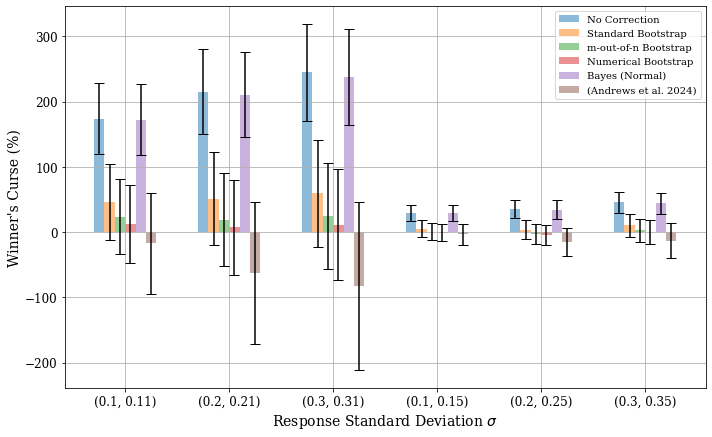

$\Delta\tau = 0.01$  \
                             $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction         Mean                             173.99   
                      Median                           159.98   
                      S.E.                              27.61   
Standard Bootstrap    Mean                              45.72   
                      Median                            28.69   
                      S.E.                              29.83   
m-out-of-n Bootstrap  Mean                              23.81   
                      Median                             2.03   
                      S.E.                              29.66   
Numerical Bootstrap   Mean                              12.84   
                      Median                           -15.47   
                      S.E.                              30.54   
Bayes (Normal)        Mean                             172.40   
                      Median                           158.52   
                      S.E.                              27.56   
(Andrews et al. 2024) Mean                             -17.30   
                      Median                            23.59   
                      S.E.                              39.60   

                                                               \
                             $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction         Mean                             214.95   
                      Median                           223.59   
                      S.E.                              33.30   
Standard Bootstrap    Mean                              51.15   
                      Median                            28.89   
                      S.E.                              36.40   
m-out-of-n Bootstrap  Mean                              19.23   
                      Median                            -7.77   
                      S.E.                              36.04   
Numerical Bootstrap   Mean                               7.51   
                      Median                           -16.21   
                      S.E.                              37.09   
Bayes (Normal)        Mean                             210.63   
                      Median                           219.23   
                      S.E.                              33.20   
(Andrews et al. 2024) Mean                             -62.92   
                      Median                            23.59   
                      S.E.                              55.47   

                                                               \
                             $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction         Mean                             245.04   
                      Median                           223.59   
                      S.E.                              37.88   
Standard Bootstrap    Mean                              59.40   
                      Median                            39.59   
                      S.E.                              41.94   
m-out-of-n Bootstrap  Mean                              24.49   
                      Median                             9.78   
                      S.E.                              41.55   
Numerical Bootstrap   Mean                              11.51   
                      Median                           -14.78   
                      S.E.                              43.08   
Bayes (Normal)        Mean                             237.42   
                      Median                           215.98   
                      S.E.                              37.76   
(Andrews et al. 2024) Mean                             -83.00   
                      Median                            -1.05   
                      S.E.                              65.88   

                                          $\Delta\tau = 0.05$  \
                             $(\tau_1, \tau_2)$ = (0.1, 0.15)   
No Correc

In [109]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in bernoulli_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in bernoulli_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(bernoulli_te_list)), labels=bernoulli_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [110]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{llllllll}
 &  & \multicolumn{3}{r}{$\Delta	au = 0.01$} & \multicolumn{3}{r}{$\Delta	au = 0.05$} \\
 &  & $(	au_1, 	au_2)$ = (0.1, 0.11) & $(	au_1, 	au_2)$ = (0.2, 0.21) & $(	au_1, 	au_2)$ = (0.3, 0.31) & $(	au_1, 	au_2)$ = (0.1, 0.15) & $(	au_1, 	au_2)$ = (0.2, 0.25) & $(	au_1, 	au_2)$ = (0.3, 0.35) \\
\multirow[c]{3}{*}{No Correction} & Mean & 173.99\% & 214.95\% & 245.04\% & 29.61\% & 35.53\% & 45.59\% \\
 & Median & 159.98\% & 223.59\% & 223.59\% & 28.36\% & 32.00\% & 52.00\% \\
 & S.E. & 27.61\% & 33.30\% & 37.88\% & 6.11\% & 7.16\% & 8.30\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 45.72\% & 51.15\% & 59.40\% & 5.35\% & 3.88\% & 10.16\% \\
 & Median & 28.69\% & 28.89\% & 39.59\% & -3.58\% & -0.82\% & 7.58\% \\
 & S.E. & 29.83\% & 36.40\% & 41.94\% & 6.62\% & 7.70\% & 9.10\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 23.81\% & 19.23\% & 24.49\% & 0.28\% & -2.75\% & 2.97\% \\
 & Median & 2.03\% & -7.77\% & 9.78\% & -7.72\% & -6.84\% & -2.12\% \\
 &

## Sample Size

In [111]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [112]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  im


Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 500
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   13.9s finished


In [113]:
with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
    pickle.dump(bernoulli_sample_size_result_dict, f)

with open('results/ab_test_bernoulli_sample_size.pkl', 'rb') as f:
    bernoulli_sample_size_result_dict = pickle.load(f)

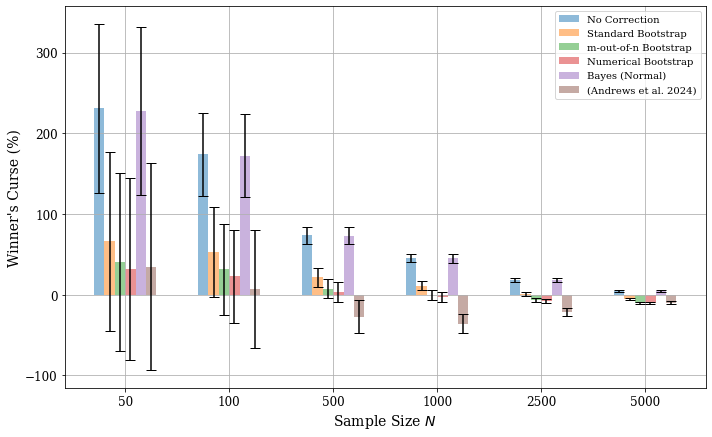

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction         Mean    231.20   174.00    73.52     45.48     18.79   
                      Median  200.00   200.00    60.00     50.00     20.00   
                      S.E.     53.42    26.47     5.46      2.74      1.20   
Standard Bootstrap    Mean     66.10    53.01    21.99     11.23      0.81   
                      Median   29.20    19.10    10.50      8.49      1.28   
                      S.E.     56.78    28.70     5.97      2.99      1.30   
m-out-of-n Bootstrap  Mean     40.47    31.55     7.63      0.07     -6.65   
                      Median    8.24    -0.35    -4.55     -2.41     -5.67   
                      S.E.     56.10    28.71     6.00      3.02      1.32   
Numerical Bootstrap   Mean     31.54    22.95     3.64     -3.17     -7.72   
                      Median   -6.93   -13.56    -9.22     -7.95     -5.03   
                      S.E.     57.59    29.54     6.16      3.13      1.36   
Bayes (Normal)        Mean    228.17   172.63    73.29     45.37     18.75   
                      Median  197.47   198.53    59.76     49.88     19.96   
                      S.E.     53.19    26.42     5.46      2.74      1.20   
(Andrews et al. 2024) Mean     34.50     6.91   -26.99    -35.83    -21.53   
                      Median   27.37    21.72    14.28     -0.16      3.65   
                      S.E.     65.44    37.41    10.25      6.05      2.50   

                              $N=5000$  
No Correction         Mean        4.42  
                      Median      2.00  
                      S.E.        0.63  
Standard Bootstrap    Mean       -4.85  
                      Median     -5.33  
                      S.E.        0.68  
m-out-of-n Bootstrap  Mean      -10.04  
                      Median    -10.33  
                      S.E.        0.70  
Numerical Bootstrap   Mean       -9.85  
                      Median    -10.08  
                      S.E.        0.72  
Bayes (Normal)        Mean        4.40  
                      Median      1.98  
                      S.E.        0.63  
(Andrews et al. 2024) Mean       -9.71  
                      Median     -2.41  
                      S.E.        1.01

In [114]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [115]:
print(wc_stats_df.map(lambda x: f'{x:.2f}\%').style.to_latex())

\begin{tabular}{llllllll}
 &  & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 231.20\% & 174.00\% & 73.52\% & 45.48\% & 18.79\% & 4.42\% \\
 & Median & 200.00\% & 200.00\% & 60.00\% & 50.00\% & 20.00\% & 2.00\% \\
 & S.E. & 53.42\% & 26.47\% & 5.46\% & 2.74\% & 1.20\% & 0.63\% \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 66.10\% & 53.01\% & 21.99\% & 11.23\% & 0.81\% & -4.85\% \\
 & Median & 29.20\% & 19.10\% & 10.50\% & 8.49\% & 1.28\% & -5.33\% \\
 & S.E. & 56.78\% & 28.70\% & 5.97\% & 2.99\% & 1.30\% & 0.68\% \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 40.47\% & 31.55\% & 7.63\% & 0.07\% & -6.65\% & -10.04\% \\
 & Median & 8.24\% & -0.35\% & -4.55\% & -2.41\% & -5.67\% & -10.33\% \\
 & S.E. & 56.10\% & 28.71\% & 6.00\% & 3.02\% & 1.32\% & 0.70\% \\
\multirow[c]{3}{*}{Numerical Bootstrap} & Mean & 31.54\% & 22.95\% & 3.64\% & -3.17\% & -7.72\% & -9.85\% \\
 & Median & -6.93\% & -13.56\% & -9.22\% & -7.95\% & -

# Sketch